# 00. PyTorch Fundamentals

In [1]:
import torch
import numpy as np

## Introduction to Tensors

Tensors are the fundamental building block of machine learning.

Their job is to represent data in a numerical way.

### Creating tensors

The first thing we need to create is a scalar.

A scalar is a single number and in tensor-speak it's a zero dimension tensor.

In [2]:
# Scalar
scalar = torch.tensor(7)
scalar

tensor(7)

check the dimensions of a tensor using the `ndim` attribute.

In [3]:
scalar.ndim

0

In [4]:
# get the item in the scalar
scalar.item()

7

**Vector**

A vector is a single dimension tensor but can contain many numbers.

In [5]:
# Vector
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [6]:
vector.ndim

1

In [7]:
vector.shape

torch.Size([2])

**Matrix**

`MATRIX` has two dimensions

In [8]:
# Matrix
MATRIX = torch.tensor([[7, 8], [9, 10]])
MATRIX

tensor([[ 7,  8],
        [ 9, 10]])

In [9]:
# Check number of dimensions
MATRIX.ndim

2

In [10]:
MATRIX.shape

torch.Size([2, 2])

In [11]:
# Tensor
TENSOR = torch.tensor([[[1, 2, 3], [3, 6, 9], [2, 4, 5]]])
TENSOR

tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [12]:
# Check number of dimensions for TENSOR
TENSOR.ndim

3

In [13]:
# Check shape of TENSOR
TENSOR.shape

torch.Size([1, 3, 3])

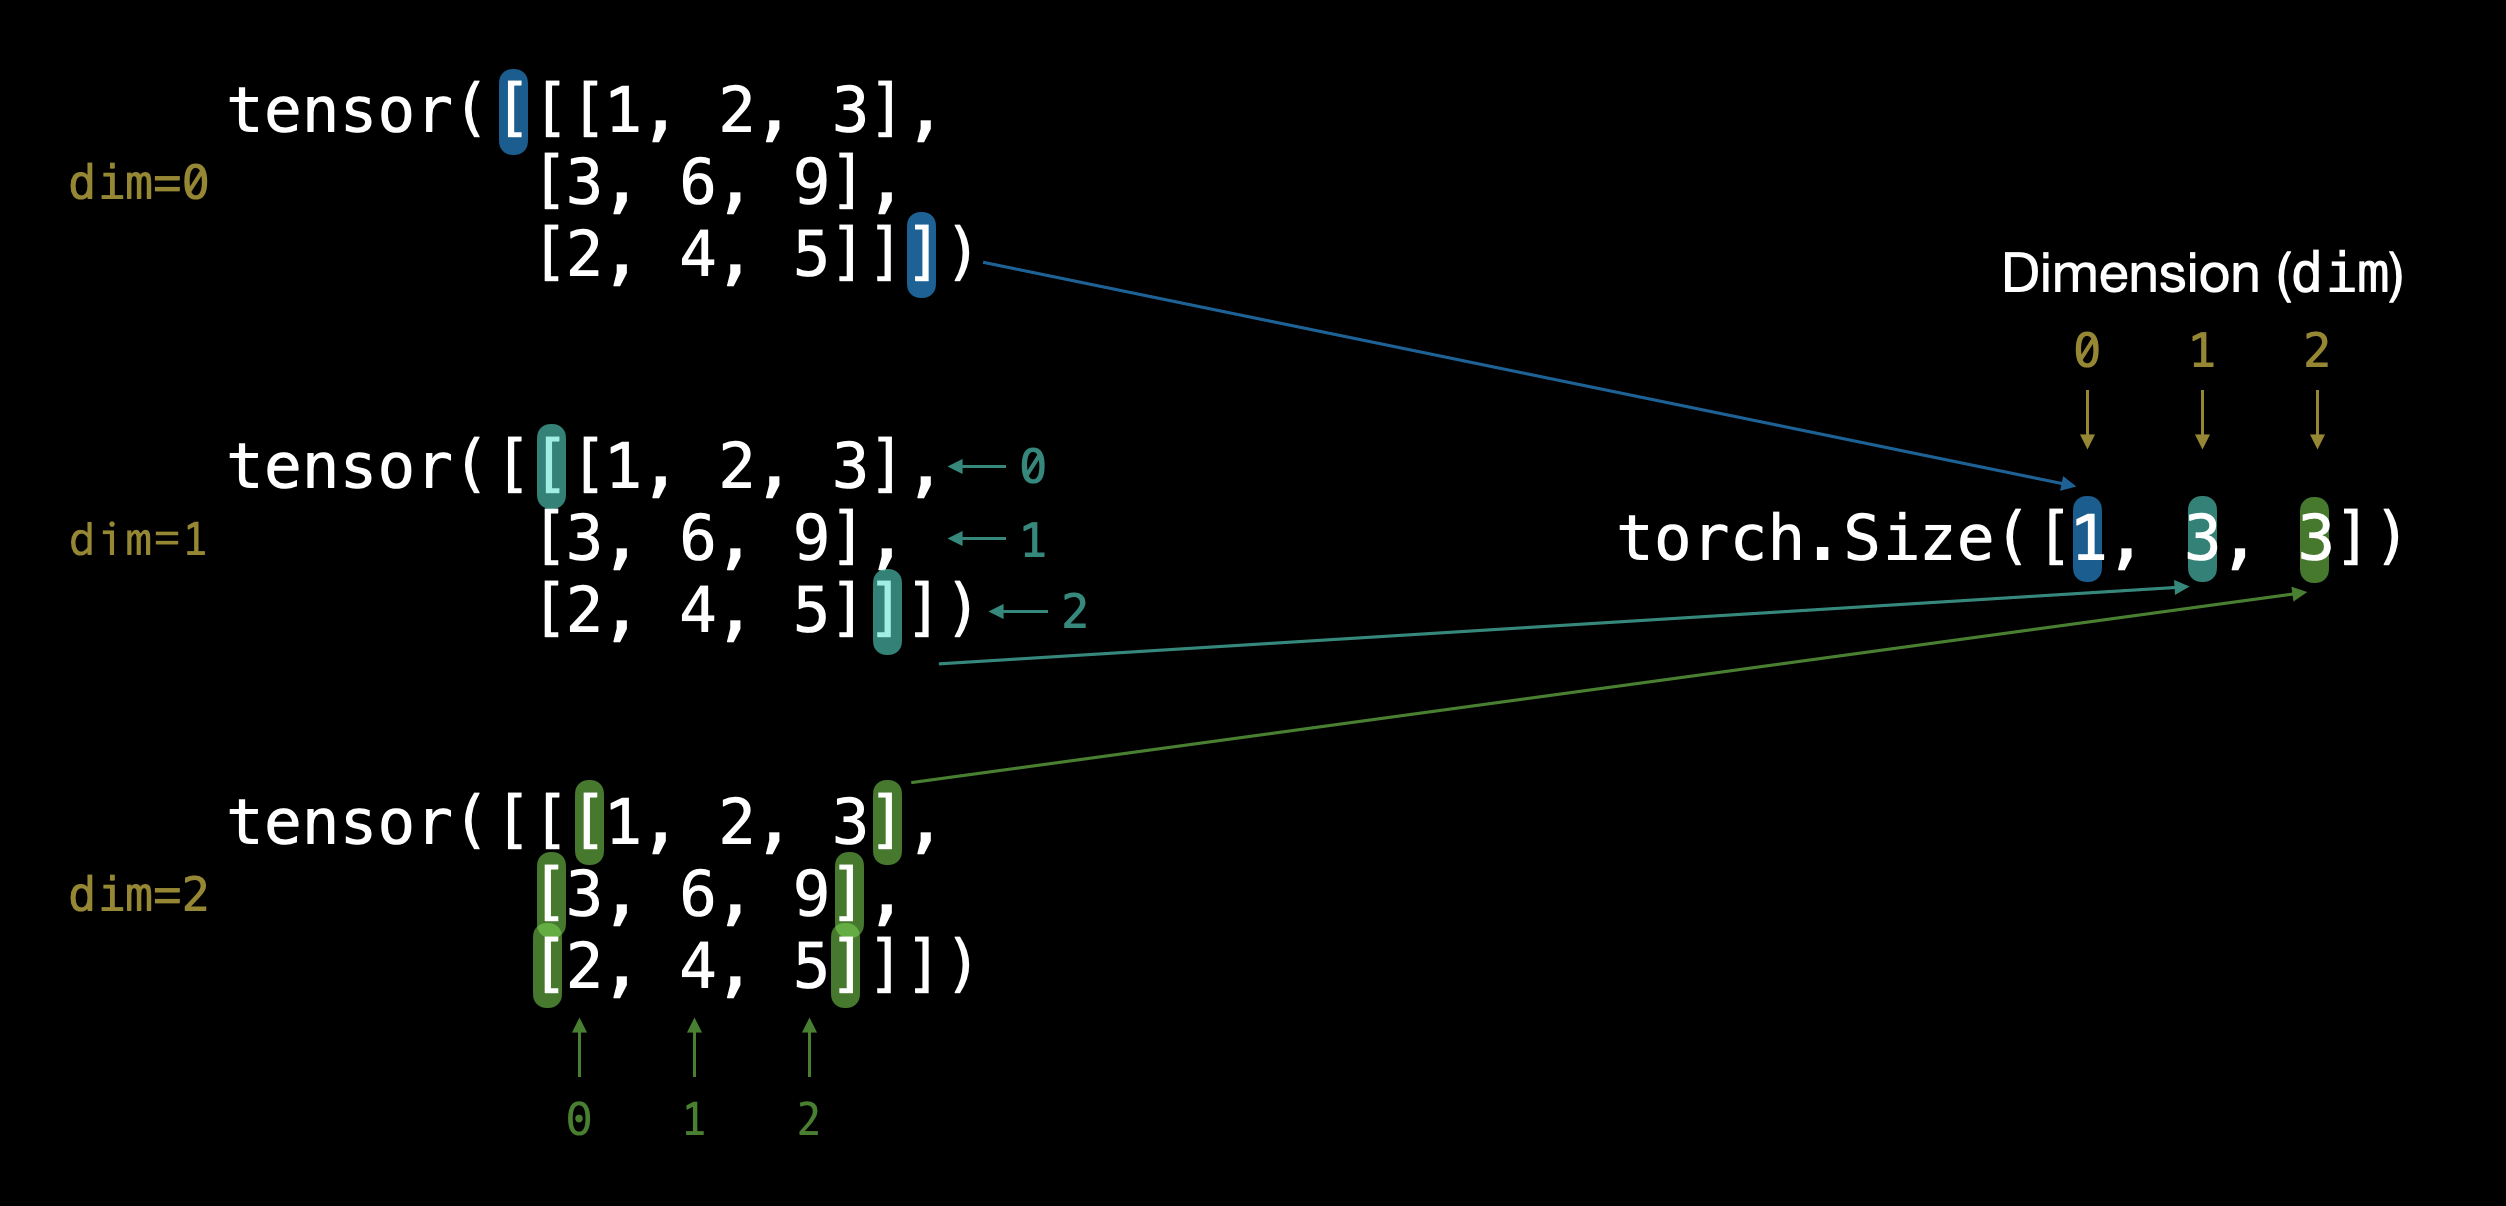

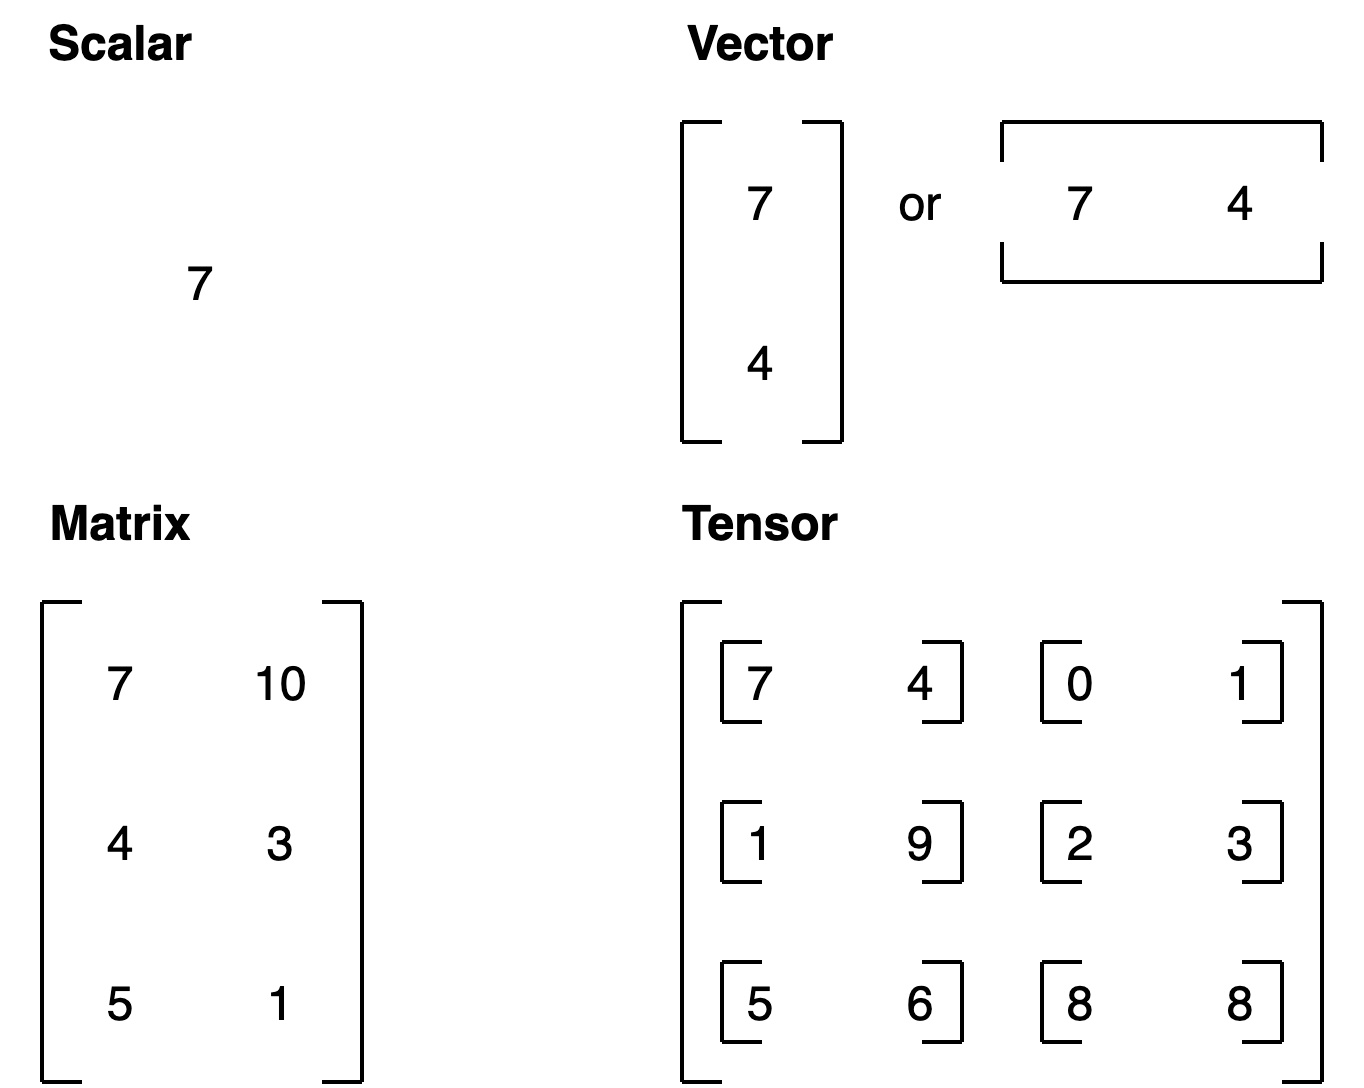

### Random tensors

In [14]:
# Create a random tensor of size (3, 4)
random_tensor = torch.rand(size=(3, 4))
random_tensor, random_tensor.dtype

(tensor([[0.8663, 0.6911, 0.8843, 0.3388],
         [0.7805, 0.3165, 0.4422, 0.2014],
         [0.8668, 0.7931, 0.9371, 0.4144]]),
 torch.float32)

In [15]:
# Create a random tensor of size (224, 224, 3)
random_image_size_tensor = torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

### Zeros and ones

In [16]:
# Create a tensor of all zeros
zeros = torch.zeros(size=(3, 4))
zeros, zeros.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

### Creating a range and tensors like

In [17]:
# Create a range of values 0 to 10
zero_to_ten = torch.arange(start=0, end=10, step=1)
zero_to_ten

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [18]:
ten_zeros = torch.zeros_like(zero_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Tensor datatypes

There are many different tensor datatypes available in PyTorch.

Some are specific for CPU and some are better for GPU.

The most common type (and generally the default) is `torch.float32` or `torch.float`.

This is referred to as "**32-bit floating point**".

But there's also 16-bit floating point (`torch.float16` or `torch.half`) and 64-bit floating point (`torch.float64` or `torch.double`).

> Note: An integer is a flat round number like 7 whereas a float has a decimal 7.0.


In [19]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor(
    [3.0, 6.0, 9.0],
    dtype=None,  # defaults to None, which is torch.float32 or whatever datatype is passed
    device=None,  # defaults to None, which uses the default tensor type
    requires_grad=False,  # if True, operations performed on the tensor are recorded
)  

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

In [20]:
# float16 tensor
float_16_tensor = torch.tensor(
    [3.0, 6.0, 9.0], dtype=torch.float16
)  # torch.half would also work

float_16_tensor.dtype


torch.float16

### Getting information from tensors

- `shape` - what shape is the tensor? (some operations require specific shape rules)
- `dtype` - what datatype are the elements within the tensor stored in?
- `device` - what device is the tensor stored on? (usually GPU or CPU)

In [21]:
some_tensor = torch.rand(3, 4)

# details
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Device of tensor: {some_tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device of tensor: cpu


### Manipulating tensors (tensor operations)

In deep learning, data (images, text, video, audio, protein structures, etc) gets represented as `tensors`.

A model learns by investigating those tensors and performing a series of operations (could be 1,000,000s+) on tensors to create a representation of the patterns in the input data.

These operations are:

- Addition
- Substraction
- Multiplication (element-wise)
- Division
- Matrix multiplication

#### Basic Operations

- addition (`+`)
- subtraction (`-`)
- multiplication (`*`)

In [22]:
tensor = torch.tensor([1, 2, 3])

In [23]:
# addition
tensor + 10

tensor([11, 12, 13])

In [24]:
# subtraction
tensor - 10

tensor([-9, -8, -7])

In [25]:
# multiplication
tensor * 10

tensor([10, 20, 30])

> Values inside the tensor don't change unless they're reassigned

In [26]:
# performing basic operations using pytorch built-in functions
print(f"addition: {tensor.add(10)}")
print(f"subtraction: {tensor.sub(10)}")
print(f"multiplication: {tensor.mul(10)}")

addition: tensor([11, 12, 13])
subtraction: tensor([-9, -8, -7])
multiplication: tensor([10, 20, 30])


#### Matrix multiplication

PyTorch implements matrix multiplication functionality in the `torch.matmul()` method.

The main two rules for matrix multiplication to remember are:

1. The **inner dimensions** must match:
  - (3, 2) @ (3, 2) won't work
  - (2, 3) @ (3, 2) will work
  - (3, 2) @ (2, 3) will work

2. The resulting matrix has the shape of the **outer dimensions**:
   - (2, 3) @ (3, 2) -> (2, 2)
   - (3, 2) @ (2, 3) -> (3, 3)

> Note: "@" in Python is the symbol for matrix multiplication.

In [27]:
tensor = torch.tensor([1, 2, 3])
tensor.shape

torch.Size([3])

The difference between element-wise multiplication and matrix multiplication is the addition of values.

For our tensor variable with values [1, 2, 3]:

| Operation	| Calculation	| Code |
| --------- | ----------- | ---- |
| **Element-wise multiplication** |	`[1*1, 2*2, 3*3] = [1, 4, 9]`	| `tensor * tensor` |
| **Matrix multiplication**	| `[1*1 + 2*2 + 3*3] = [14]`	| `tensor.matmul(tensor) `|

In [28]:
# Element-wise matrix multiplication
tensor * tensor

tensor([1, 4, 9])

In [29]:
# matrix multiplication
torch.matmul(tensor, tensor) # tensor.matmul(tensor) - this too works

tensor(14)

In [30]:
# using @ symbol
tensor @ tensor

tensor(14)

The in-built torch.matmul() method is faster

In [31]:
%%time

# matrix multiplication by using for loops

value = 0
for i in range(0, len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 678 μs, sys: 872 μs, total: 1.55 ms
Wall time: 1.31 ms


tensor(14)

In [32]:
%%time

# matrix multiplication by using built-in functions

torch.matmul(tensor, tensor)

CPU times: user 23 μs, sys: 1 μs, total: 24 μs
Wall time: 26.9 μs


tensor(14)

Because much of deep learning is multiplying and performing operations on matrices and matrices have a strict rule about what shapes and sizes can be combined, one of the most common errors you'll run into in deep learning is shape mismatches.

In [33]:
# Tensors
tensor_A = torch.tensor([[1, 2], [3, 4], [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10], [8, 11], [9, 12]], dtype=torch.float32)

print(f"Tensor A: {tensor_A} \nshape: {tensor_A.shape}")
print(f"Tensor B: {tensor_B} \nshape: {tensor_B.shape}")

print(f"tensor_A * tensor_B: {torch.matmul(tensor_A, tensor_B)}") # (this will error)

Tensor A: tensor([[1., 2.],
        [3., 4.],
        [5., 6.]]) 
shape: torch.Size([3, 2])
Tensor B: tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]]) 
shape: torch.Size([3, 2])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

We can make matrix multiplication work between `tensor_A` and `tensor_B` by making their inner dimensions match.

One of the ways to do this is with a **transpose** (switch the dimensions of a given tensor).

In [34]:
tensor_B_T = tensor_B.T

print(f"Tensor A: {tensor_A} \nshape: {tensor_A.shape}")
print(f"Tensor B: {tensor_B} \nshape: {tensor_B.shape}")
print(f"Transposed Tensor B: {tensor_B_T} \nshape: {tensor_B_T.shape}")

output = torch.matmul(tensor_A, tensor_B_T)
print(f"tensor_A * tensor_B_T: {output} \nshape: {output.shape}")

Tensor A: tensor([[1., 2.],
        [3., 4.],
        [5., 6.]]) 
shape: torch.Size([3, 2])
Tensor B: tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]]) 
shape: torch.Size([3, 2])
Transposed Tensor B: tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]]) 
shape: torch.Size([2, 3])
tensor_A * tensor_B_T: tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]]) 
shape: torch.Size([3, 3])


`torch.mm()` is a short for `torch.matmul()`

In [35]:
# torch.mm is a shortcut for matmul
torch.mm(tensor_A, tensor_B.T)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

> Note: A matrix multiplication like this is also referred to as the **dot product** of two matrices.

Neural networks are full of **matrix multiplications** and **dot products**.

The `torch.nn.Linear()` module, also known as a feed-forward layer or fully connected layer, implements a matrix multiplication between an input `x` and a weights matrix `A`.

$$ y = x\cdot{A^T} + b $$

Where:

- `x` is the input to the layer (deep learning is a stack of layers like `torch.nn.Linear()` and others on top of each other).
- `A` is the weights matrix created by the layer, this starts out as random numbers that get adjusted as a neural network learns to better represent patterns in the data (notice the "T", that's because the weights matrix gets transposed).
  
  - **Note:** You might also often see `W` or another letter like `X` used to showcase the weights matrix.

- `b` is the bias term used to slightly offset the weights and inputs.
- `y` is the output (a manipulation of the input in the hopes to discover patterns in it).

This is a linear function $y = mx+b$

In [36]:
# Since the linear layer starts with a random weights matrix
torch.manual_seed(42)

# This uses matrix multiplication
linear = torch.nn.Linear(
    in_features=2,  # in_features = matches inner dimension of input
    out_features=6,  # out_features = describes outer value
)  
x = tensor_A
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")


Input shape: torch.Size([3, 2])

Output:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


### Aggregations (min, max, mean, sum, etc)

In [37]:
# Create a tensor
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [38]:
print(f"Minimum: {x.min()}")
print(f"Maximum: {x.max()}")
# print(f"Mean: {x.mean()}") # this will result in error
print(f"Mean: {x.type(torch.float32).mean()}") # Mean will work when datatype is specified.
print(f"Sum: {x.sum()}")

Minimum: 0
Maximum: 90
Mean: 45.0
Sum: 450


#### Positional min/max

You can also find the index of a tensor where the max or minimum occurs with `torch.argmax()` and `torch.argmin()` respectively.

In [39]:
print(f"Tensor: {x}\n")

print(f"Minimum: {x.min()}, Index value of min value: {x.argmin()}")
print(f"Maximum: {x.max()}, Index value of max value: {x.argmax()}")


Tensor: tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

Minimum: 0, Index value of min value: 0
Maximum: 90, Index value of max value: 9


### Change tensor datatype

In [40]:
# Create a tensor and check its datatype
tensor = torch.arange(10.0, 100.0, 10.0)
tensor, tensor.dtype

(tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.]), torch.float32)

In [41]:
# Create a float16 tensor
tensor_float16 = tensor.type(torch.float16)
tensor_float16

tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.], dtype=torch.float16)

In [42]:
# Create an int8 tensor
tensor_int8 = tensor.type(torch.int8)
tensor_int8

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)

### Reshaping, stacking, squeezing and unsqueezing

| Method | One-line description |
| ------ | -------------------- |
| `torch.reshape(input, shape)	` | Reshapes input to shape (if compatible), can also use `torch.Tensor.reshape()`.
| `Tensor.view(shape)`	| Returns a view of the original tensor in a different shape but shares the same data as the original tensor. |
| `torch.stack(tensors, dim=0)	`| Concatenates a sequence of tensors along a new dimension (dim), all tensors must be same size. |
| `torch.squeeze(input)`	| Squeezes input to remove all the dimenions with value 1. |
| `torch.unsqueeze(input, dim)`	| Returns input with a dimension value of 1 added at dim. |
| `torch.permute(input, dims)`	| Returns a view of the original input with its dimensions permuted (rearranged) to dims. |

> Why do any of these?
> 
> Because deep learning models (neural networks) are all about manipulating tensors in some way. And because of the rules of matrix multiplication, if you've got shape mismatches, you'll run into errors. These methods help you make sure the right elements of your tensors are mixing with the right elements of other tensors.

In [43]:
# Create a tensor
import torch

x = torch.arange(1.0, 8.0)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

Now let's add an extra dimension with `torch.reshape()`.

In [44]:
# Add an extra dimension
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape


(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [45]:
z = x.view(1, 7)
x, z, z.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]),
 tensor([[1., 2., 3., 4., 5., 6., 7.]]),
 torch.Size([1, 7]))

Changing the view of a tensor with `torch.view()` really only creates a new view of the same tensor.

So changing the view changes the original tensor too.

In [46]:
# Changing z changes x
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7.]]), tensor([5., 2., 3., 4., 5., 6., 7.]))

In [47]:
# Stack tensors on top of each other
x_stacked = torch.stack(
    [x, x, x, x], dim=0
) 
x_stacked

tensor([[5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.]])

In [48]:
# Stack tensors on top of each other
x_stacked = torch.stack(
    [x, x, x, x], dim=1
)
x_stacked

tensor([[5., 5., 5., 5.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.]])

In [49]:
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape: {x_reshaped.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Previous shape: torch.Size([1, 7])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
New shape: torch.Size([7])


Rearrange the order of axes values with `torch.permute(input, dims)`, where the input gets turned into a view with new dims.

In [50]:
# Create tensor with specific shape
x_original = torch.rand(size=(224, 225, 3))

# Permute the original tensor to rearrange the axis order
x_permuted = x_original.permute(2, 0, 1)  # shifts axis 0->1, 1->2, 2->0

print(f"Previous shape: {x_original.shape}")
print(f"New shape: {x_permuted.shape}")


Previous shape: torch.Size([224, 225, 3])
New shape: torch.Size([3, 224, 225])


### Indexing (selecting data from tensors)

In [51]:
# Create a tensor
import torch

x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [52]:
# Let's index bracket by bracket
print(f"First square bracket:\n{x[0]}")
print(f"Second square bracket: {x[0][0]}")
print(f"Third square bracket: {x[0][0][0]}")

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1


In [53]:
# Get all values of 0th dimension and the 0 index of 1st dimension
x[:, 0]

tensor([[1, 2, 3]])

In [54]:
# Get all values of 0th & 1st dimensions but only index 1 of 2nd dimension
x[:, :, 1]

tensor([[2, 5, 8]])

In [55]:
# Get all values of the 0 dimension but only the 1 index value of the 1st and 2nd dimension
x[:, 1, 1]

tensor([5])

In [56]:
# Get index 0 of 0th and 1st dimension and all values of 2nd dimension
x[0, 0, :]  # same as x[0][0]

tensor([1, 2, 3])

In [57]:
# first 2 columns
x[0, :3, :2]

tensor([[1, 2],
        [4, 5],
        [7, 8]])

### PyTorch tensors & NumPy

The two main methods to use for NumPy to PyTorch are:

- `torch.from_numpy(ndarray)` - NumPy array -> PyTorch tensor.
- `torch.Tensor.numpy()` - PyTorch tensor -> NumPy array.

In [58]:
# NumPy array to tensor
array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [59]:
# Change the array, keep the tensor
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [60]:
# Tensor to NumPy array
tensor = torch.ones(7)  # create a tensor of ones with dtype=float32
numpy_tensor = tensor.numpy()  # will be dtype=float32 unless changed
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [61]:
# Change the tensor, keep the array the same
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### Reproducibility

In [62]:
# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print("Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B


Tensor A:
tensor([[0.7029, 0.0650, 0.1280, 0.0728],
        [0.4482, 0.8423, 0.3919, 0.1191],
        [0.7616, 0.9423, 0.8760, 0.9324]])

Tensor B:
tensor([[0.3308, 0.0646, 0.4916, 0.1255],
        [0.5787, 0.1763, 0.2929, 0.6503],
        [0.6766, 0.5110, 0.7881, 0.4820]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

if you wanted to create two random tensors with the same values.

That's where `torch.manual_seed(seed)` comes in, where seed is an integer (like 42 but it could be anything) that flavours the randomness.

In [63]:
# # Set the random seed
RANDOM_SEED = 42 
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

# Have to reset the seed every time a new rand() is called
# Without this, tensor_D would be different to tensor_C
torch.random.manual_seed(
    seed=RANDOM_SEED
)
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print("Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D


Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

### Running tensors on GPUs (and making faster computations)


Deep learning algorithms require a lot of numerical operations.

And by default these operations are often done on a CPU (computer processing unit).

However, there's another common piece of hardware called a GPU (graphics processing unit), which is often much faster at performing the specific types of operations neural networks need (matrix multiplications) than CPUs.

In [64]:
# Check for GPU
torch.cuda.is_available()

False

In [65]:
device = ''
if torch.cuda.is_available():
    device = "cuda"  # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps"  # Use Apple Silicon GPU (if available)
else:
    device = "cpu"  # Default to CPU if no GPU is available
    
device

'mps'

In [66]:
# Count number of devices
torch.cuda.device_count() | torch.mps.device_count()

1

In [67]:
# Create tensor (default on CPU)
tensor = torch.tensor([1, 2, 3])

# Tensor not on GPU
print(tensor, tensor.device)

# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3]) cpu


tensor([1, 2, 3], device='mps:0')

In [68]:
# If tensor is on GPU, can't transform it to NumPy (this will error)
tensor_on_gpu.numpy()

TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

Instead, to get a tensor back to CPU and usable with NumPy we can use `Tensor.cpu()`.

This copies the tensor to CPU memory so it's usable with CPUs.

In [69]:
# Instead, copy the tensor back to cpu
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

array([1, 2, 3])